# 12-831 Final Project Notebook

## Member 1 + Member 2 Pipeline

This notebook is scoped to the first two team deliverables for the full `2025-11-04 Final Project Train Runs` dataset.

What this notebook does:
- fixes Member 1 data discovery, label parsing, synchronization, and export
- builds 1-second window features for Member 2
- trains a grouped digital twin regression baseline for expected vibration
- exports `run_metadata.csv`, `aligned_runs.csv`, `window_features.csv`, and `digital_twin_predictions.csv`

Project framing:
- Arduino telemetry provides operating context
- DAQ accelerometers provide measured vibration
- the digital twin predicts expected vibration from context
- residuals quantify deviation between expected and measured behavior
            


## 1. Setup
I used **python 3.11.5** environment.

This notebook works both locally and in Colab. If you run it in Colab, update the Google Drive candidate path list if your folder lives somewhere else.
            


In [ ]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)

try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except ImportError:
    drive = None
    IN_COLAB = False

DATASET_NAME = '2025-11-04 Final Project Train Runs'
BASE_DIR_CANDIDATES = [
    Path.cwd() / DATASET_NAME,
    Path(DATASET_NAME),
    Path('/content/drive/MyDrive/12831 digital twin and AI final project') / DATASET_NAME,
    Path('/content/drive/MyDrive/12831 Final Project') / DATASET_NAME,
    Path('/content/drive/MyDrive') / DATASET_NAME,
]

BASE_DIR = next((candidate for candidate in BASE_DIR_CANDIDATES if candidate.exists()), None)

if BASE_DIR is None and IN_COLAB:
    drive.mount('/content/drive')
    BASE_DIR = next((candidate for candidate in BASE_DIR_CANDIDATES if candidate.exists()), None)

if BASE_DIR is None:
    raise FileNotFoundError(
        'Could not find the dataset folder. Update BASE_DIR_CANDIDATES so one of them points to '
        f'{DATASET_NAME!r}.'
    )

TARGET_HZ = 25
WINDOW_S = 1.0
REQUIRED_FILES = ['arduino_motion_raw.csv', 'daq_sensors_1000hz.csv', 'metadata.json']

print('Using BASE_DIR:', BASE_DIR)
print('Target alignment rate (Hz):', TARGET_HZ)



Using BASE_DIR: /content/drive/MyDrive/12831 digital twin and AI final project/2025-11-04 Final Project Train Runs
Target alignment rate (Hz): 25


## 2. Member 1: Discover Runs, Parse Labels, and Align Signals

The full dataset is organized as:
`material / condition / run_id / files`

This section fixes the common issues in Part 1:
- discovers all 108 runs
- parses material, thickness, load, placement, and speed labels
- reads JSON-lines metadata safely
- aligns Arduino and DAQ streams onto one 25 Hz timeline
- exports run-level metadata and the aligned row-level dataset
            


In [ ]:
def token_to_float(token):
    if token is None:
        return np.nan
    return float(str(token).replace('_', '.'))


def parse_material_label(name):
    name_l = str(name).lower()
    material_type = 'unknown'
    if 'aluminum' in name_l:
        material_type = 'aluminum'
    elif 'steel' in name_l:
        material_type = 'steel'

    thickness = np.nan
    match = re.search(r'(\d+)_(\d+)_in', name_l)
    if match:
        thickness = float(match.group(1)) / float(match.group(2))

    return {
        'material': name,
        'material_type': material_type,
        'material_thickness_in': thickness,
    }


def parse_condition_label(condition_name):
    raw = str(condition_name)
    name = raw.lower()

    parsed = {
        'condition_name': raw,
        'condition_group': 'loaded',
        'experiment_group': 'other',
        'speed_fps_from_name': np.nan,
        'speed_label_from_name': 'unknown',
        'load_label': 'unknown',
        'placement_label': 'unknown',
        'total_load_kg_est': np.nan,
    }

    if name == 'baseline':
        parsed.update({
            'condition_group': 'baseline',
            'experiment_group': 'baseline',
            'load_label': 'no_load',
            'placement_label': 'baseline',
            'total_load_kg_est': 0.0,
        })
        return parsed

    if name == 'half_loaded_train':
        parsed.update({
            'experiment_group': 'train_loading',
            'load_label': 'half_loaded_train',
            'placement_label': 'distributed_train',
            'total_load_kg_est': 2.0,
        })
        return parsed

    if name == 'fully_loaded_train':
        parsed.update({
            'experiment_group': 'train_loading',
            'load_label': 'fully_loaded_train',
            'placement_label': 'distributed_train',
            'total_load_kg_est': 4.0,
        })
        return parsed

    speed_case = re.search(r'(\d+(?:_\d+)?)_kg_location_([abc])_unclipped_(\d+(?:_\d+)?)fps', name)
    if speed_case:
        load_kg = token_to_float(speed_case.group(1))
        speed_fps = token_to_float(speed_case.group(3))
        parsed.update({
            'experiment_group': 'speed_test',
            'load_label': f'{load_kg:g}kg_single',
            'placement_label': f'location_{speed_case.group(2).upper()}',
            'total_load_kg_est': load_kg,
            'speed_fps_from_name': speed_fps,
            'speed_label_from_name': f'{speed_fps:g}fps',
        })
        return parsed

    location_case = re.search(r'(\d+(?:_\d+)?)kg_location_([abc])', name)
    if location_case:
        load_kg = token_to_float(location_case.group(1))
        parsed.update({
            'experiment_group': 'placement_test',
            'load_label': f'{load_kg:g}kg_single',
            'placement_label': f'location_{location_case.group(2).upper()}',
            'total_load_kg_est': load_kg,
        })
        return parsed

    each_peg_case = re.search(r'(\d+(?:_\d+)?)_kg_ea_peg', name)
    if each_peg_case:
        each_kg = token_to_float(each_peg_case.group(1))
        parsed.update({
            'experiment_group': 'load_distribution',
            'load_label': f'{each_kg:g}kg_each_peg',
            'placement_label': 'all_pegs',
            'total_load_kg_est': each_kg * 4,
        })
        return parsed

    left_pegs_case = re.search(r'(\d+(?:_\d+)?)kg_ea_left_pegs', name)
    if left_pegs_case:
        each_kg = token_to_float(left_pegs_case.group(1))
        parsed.update({
            'experiment_group': 'load_distribution',
            'load_label': f'{each_kg:g}kg_each_left_peg',
            'placement_label': 'left_pegs',
            'total_load_kg_est': each_kg * 2,
        })
        return parsed

    split_case = re.search(r'(\d+(?:_\d+)?)kg_ea_a_left_c_right', name)
    if split_case:
        each_kg = token_to_float(split_case.group(1))
        parsed.update({
            'experiment_group': 'load_distribution',
            'load_label': f'{each_kg:g}kg_each_split',
            'placement_label': 'a_left_c_right',
            'total_load_kg_est': each_kg * 2,
        })
        return parsed

    return parsed


def read_metadata_records(metadata_path):
    records = []
    if not metadata_path.exists():
        return records

    for line in metadata_path.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            pass
    return records


def extract_speed_fps(metadata_records, condition_info):
    candidates = []
    for record in metadata_records:
        if not isinstance(record, dict):
            continue
        for key in ('arduino_params', 'arduino_defaults', 'user_params'):
            block = record.get(key)
            if isinstance(block, dict) and 'VMAX_FPS' in block:
                try:
                    candidates.append(float(block['VMAX_FPS']))
                except (TypeError, ValueError):
                    pass

    if not pd.isna(condition_info['speed_fps_from_name']):
        return condition_info['speed_fps_from_name']
    if candidates:
        return candidates[-1]
    return np.nan


def discover_runs(base_dir):
    rows = []
    for material_dir in sorted(base_dir.iterdir()):
        if not material_dir.is_dir():
            continue

        material_info = parse_material_label(material_dir.name)

        for condition_dir in sorted(material_dir.iterdir()):
            if not condition_dir.is_dir():
                continue

            condition_info = parse_condition_label(condition_dir.name)

            for run_dir in sorted(condition_dir.iterdir()):
                if not run_dir.is_dir():
                    continue

                files = {p.name for p in run_dir.iterdir() if p.is_file()}
                missing = sorted(set(REQUIRED_FILES) - files)
                metadata_records = read_metadata_records(run_dir / 'metadata.json')
                speed_fps = extract_speed_fps(metadata_records, condition_info)
                if pd.isna(speed_fps):
                    speed_label = condition_info['speed_label_from_name']
                else:
                    speed_label = f'{speed_fps:g}fps'

                rows.append({
                    'run_id': run_dir.name,
                    'run_dir': run_dir,
                    **material_info,
                    **condition_info,
                    'speed_fps': speed_fps,
                    'speed_label': speed_label,
                    'missing_required_files': ', '.join(missing),
                    'is_broken_run': bool(missing),
                })

    return pd.DataFrame(rows).sort_values(['material', 'condition_name', 'run_id']).reset_index(drop=True)


runs_df = discover_runs(BASE_DIR)
print('Discovered runs:', len(runs_df))
print('Broken runs:', int(runs_df['is_broken_run'].sum()))
display(runs_df.head())
display(runs_df[['material', 'condition_name']].value_counts().rename('run_count').reset_index().head(15))



Discovered runs: 108
Broken runs: 0


,run_id,run_dir,material,material_type,material_thickness_in,condition_name,condition_group,experiment_group,speed_fps_from_name,speed_label_from_name,load_label,placement_label,total_load_kg_est,speed_fps,speed_label,missing_required_files,is_broken_run
0,20251104_144659__unknown,/content/drive/MyDrive/12831 digital twin and ...,Aluminum_1_2_in,aluminum,0.5,0_5_kg_Ea_Peg,loaded,load_distribution,NaN,unknown,0.5kg_each_peg,all_pegs,2.0,1.25,1.25fps,,False
1,20251104_144751__unknown,/content/drive/MyDrive/12831 digital twin and ...,Aluminum_1_2_in,aluminum,0.5,0_5_kg_Ea_Peg,loaded,load_distribution,NaN,unknown,0.5kg_each_peg,all_pegs,2.0,1.25,1.25fps,,False
2,20251104_144844__unknown,/content/drive/MyDrive/12831 digital twin and ...,Aluminum_1_2_in,aluminum,0.5,0_5_kg_Ea_Peg,loaded,load_distribution,NaN,unknown,0.5kg_each_peg,all_pegs,2.0,1.25,1.25fps,,False
3,20251104_143904__unknown,/content/drive/MyDrive/12831 digital twin and ...,Aluminum_1_2_in,aluminum,0.5,1_5kg_Ea_Left_Pegs,loaded,load_distribution,NaN,unknown,1.5kg_each_left_peg,left_pegs,3.0,1.25,1.25fps,,False
4,20251104_144004__unknown,/content/drive/MyDrive/12831 digital twin and ...,Aluminum_1_2_in,aluminum,0.5,1_5kg_Ea_Left_Pegs,loaded,load_distribution,NaN,unknown,1.5kg_each_left_peg,left_pegs,3.0,1.25,1.25fps,,False


,material,condition_name,run_count
0,Aluminum_1_2_in,0_5_kg_Ea_Peg,3
1,Aluminum_1_2_in,1_5kg_Ea_Left_Pegs,3
2,Aluminum_1_2_in,2kg_Ea_A_Left_C_Right,3
3,Aluminum_1_2_in,4_kg_Location_C_Unclipped_1_5fps,3
4,Aluminum_1_2_in,4_kg_Location_C_Unclipped_3fps,3
5,Aluminum_1_2_in,4_kg_Location_C_Unclipped_6fps,3
6,Aluminum_1_2_in,4kg_Location_A,3
7,Aluminum_1_2_in,4kg_Location_B,3
8,Aluminum_1_2_in,4kg_Location_C,3
9,Aluminum_1_2_in,Baseline,3


In [ ]:
def load_run(run_dir):
    arduino = pd.read_csv(run_dir / 'arduino_motion_raw.csv')
    daq = pd.read_csv(run_dir / 'daq_sensors_1000hz.csv')
    metadata_records = read_metadata_records(run_dir / 'metadata.json')
    return arduino, daq, metadata_records


sample_row = runs_df.iloc[0]
arduino_df, daq_df, metadata_records = load_run(sample_row.run_dir)
print('Sample run:', sample_row.run_id)
display(arduino_df.head())
display(daq_df.head())
print('Metadata records read:', len(metadata_records))

Sample run: 20251104_144659__unknown


,time_ms,time_ts,phase,pos_steps,pos_ft,vel_fps,acc_fps2,t_ms
0,2840975,1.762286e+09,ACCEL,0,0.00000,0.12,0.06749,2840975
1,2840980,1.762286e+09,ACCEL,0,0.00000,0.12,0.06749,2840980
2,2840985,1.762286e+09,ACCEL,1,0.00491,0.12,0.06763,2840985
3,2840990,1.762286e+09,ACCEL,1,0.00491,0.12,0.06763,2840990
4,2840995,1.762286e+09,ACCEL,1,0.00491,0.12,0.06763,2840995


,time_ms,time_ts,v4,v5,g4,g5
0,2840985,1.762286e+09,2.494766,2.516205,-0.002617,0.008102
1,2840985,1.762286e+09,2.495406,2.516525,-0.002297,0.008262
2,2840985,1.762286e+09,2.495086,2.516525,-0.002457,0.008262
3,2840985,1.762286e+09,2.495086,2.516845,-0.002457,0.008422
4,2840985,1.762286e+09,2.495406,2.517485,-0.002297,0.008742


Metadata records read: 2


In [ ]:
def align_run(arduino_df, daq_df, target_hz=25):
    arduino = arduino_df.copy().sort_values('time_ts').drop_duplicates('time_ts')
    daq = daq_df.copy().sort_values('time_ts').drop_duplicates('time_ts')

    arduino['time_s'] = arduino['time_ts'] - arduino['time_ts'].min()
    daq['time_s'] = daq['time_ts'] - daq['time_ts'].min()

    start = max(float(arduino['time_s'].min()), float(daq['time_s'].min()))
    end = min(float(arduino['time_s'].max()), float(daq['time_s'].max()))
    if end <= start:
        raise ValueError('DAQ and Arduino timelines do not overlap.')

    grid = np.arange(start, end, 1 / target_hz)
    if len(grid) == 0:
        raise ValueError('Alignment grid is empty.')

    aligned = pd.DataFrame({'time_s': grid})
    for col in ['g4', 'g5']:
        aligned[col] = np.interp(grid, daq['time_s'], daq[col])

    for col in ['pos_ft', 'vel_fps', 'acc_fps2']:
        aligned[col] = np.interp(grid, arduino['time_s'], arduino[col])

    phase_idx = np.searchsorted(arduino['time_s'].to_numpy(), grid, side='right') - 1
    phase_idx = np.clip(phase_idx, 0, len(arduino) - 1)
    aligned['phase'] = arduino.iloc[phase_idx]['phase'].to_numpy()

    aligned['g_mean'] = aligned[['g4', 'g5']].mean(axis=1)
    aligned['g_diff'] = aligned['g5'] - aligned['g4']
    return aligned


aligned_sample = align_run(arduino_df, daq_df, target_hz=TARGET_HZ)
display(aligned_sample.head())
print('Aligned sample shape:', aligned_sample.shape)



,time_s,g4,g5,pos_ft,vel_fps,acc_fps2,phase,g_mean,g_diff
0,0.00,-0.002617,0.008102,0.000000,0.12,0.067490,ACCEL,0.002743,0.010719
1,0.04,0.001493,0.015293,0.000000,0.12,0.067490,ACCEL,0.008393,0.013800
2,0.08,0.003456,0.015142,0.000000,0.12,0.067490,ACCEL,0.009299,0.011686
3,0.12,-0.000448,0.022679,0.030457,0.12,0.068338,ACCEL,0.011116,0.023127
4,0.16,0.001119,0.036872,0.032669,0.12,0.068400,ACCEL,0.018995,0.035753


Aligned sample shape: (984, 9)


In [ ]:
all_frames = []
status_rows = []

for row in runs_df.itertuples(index=False):
    status = {
        'run_id': row.run_id,
        'material': row.material,
        'condition_name': row.condition_name,
        'status': 'ok',
        'issue': '',
    }

    if row.is_broken_run:
        status['status'] = 'missing_files'
        status['issue'] = row.missing_required_files
        status_rows.append(status)
        continue

    try:
        arduino_df, daq_df, _ = load_run(row.run_dir)
        merged = align_run(arduino_df, daq_df, target_hz=TARGET_HZ)
        merged['run_id'] = row.run_id
        merged['material'] = row.material
        merged['material_type'] = row.material_type
        merged['material_thickness_in'] = row.material_thickness_in
        merged['condition_name'] = row.condition_name
        merged['condition_group'] = row.condition_group
        merged['experiment_group'] = row.experiment_group
        merged['speed_fps'] = row.speed_fps
        merged['speed_label'] = row.speed_label
        merged['load_label'] = row.load_label
        merged['placement_label'] = row.placement_label
        merged['total_load_kg_est'] = row.total_load_kg_est
        all_frames.append(merged)
    except Exception as exc:
        status['status'] = 'failed'
        status['issue'] = str(exc)

    status_rows.append(status)

run_status_df = pd.DataFrame(status_rows)
run_metadata_df = runs_df.merge(
    run_status_df[['run_id', 'status', 'issue']],
    on='run_id',
    how='left',
)
full_df = pd.concat(all_frames, ignore_index=True)

print('Successful runs:', int((run_metadata_df['status'] == 'ok').sum()))
print('Aligned dataset shape:', full_df.shape)
display(run_metadata_df.head())
display(full_df.head())

run_metadata_df.to_csv('run_metadata.csv', index=False)
full_df.to_csv('aligned_runs.csv', index=False)
print('Saved run_metadata.csv and aligned_runs.csv')



Successful runs: 108
Aligned dataset shape: (106986, 21)


,run_id,run_dir,material,material_type,material_thickness_in,condition_name,condition_group,experiment_group,speed_fps_from_name,speed_label_from_name,load_label,placement_label,total_load_kg_est,speed_fps,speed_label,missing_required_files,is_broken_run,status,issue
0,20251104_144659__unknown,/content/drive/MyDrive/12831 digital twin and ...,Aluminum_1_2_in,aluminum,0.5,0_5_kg_Ea_Peg,loaded,load_distribution,NaN,unknown,0.5kg_each_peg,all_pegs,2.0,1.25,1.25fps,,False,ok,
1,20251104_144751__unknown,/content/drive/MyDrive/12831 digital twin and ...,Aluminum_1_2_in,aluminum,0.5,0_5_kg_Ea_Peg,loaded,load_distribution,NaN,unknown,0.5kg_each_peg,all_pegs,2.0,1.25,1.25fps,,False,ok,
2,20251104_144844__unknown,/content/drive/MyDrive/12831 digital twin and ...,Aluminum_1_2_in,aluminum,0.5,0_5_kg_Ea_Peg,loaded,load_distribution,NaN,unknown,0.5kg_each_peg,all_pegs,2.0,1.25,1.25fps,,False,ok,
3,20251104_143904__unknown,/content/drive/MyDrive/12831 digital twin and ...,Aluminum_1_2_in,aluminum,0.5,1_5kg_Ea_Left_Pegs,loaded,load_distribution,NaN,unknown,1.5kg_each_left_peg,left_pegs,3.0,1.25,1.25fps,,False,ok,
4,20251104_144004__unknown,/content/drive/MyDrive/12831 digital twin and ...,Aluminum_1_2_in,aluminum,0.5,1_5kg_Ea_Left_Pegs,loaded,load_distribution,NaN,unknown,1.5kg_each_left_peg,left_pegs,3.0,1.25,1.25fps,,False,ok,


,time_s,g4,g5,pos_ft,vel_fps,acc_fps2,phase,g_mean,g_diff,run_id,material,material_type,material_thickness_in,condition_name,condition_group,experiment_group,speed_fps,speed_label,load_label,placement_label,total_load_kg_est
0,0.00,-0.002617,0.008102,0.000000,0.12,0.067490,ACCEL,0.002743,0.010719,20251104_144659__unknown,Aluminum_1_2_in,aluminum,0.5,0_5_kg_Ea_Peg,loaded,load_distribution,1.25,1.25fps,0.5kg_each_peg,all_pegs,2.0
1,0.04,0.001493,0.015293,0.000000,0.12,0.067490,ACCEL,0.008393,0.013800,20251104_144659__unknown,Aluminum_1_2_in,aluminum,0.5,0_5_kg_Ea_Peg,loaded,load_distribution,1.25,1.25fps,0.5kg_each_peg,all_pegs,2.0
2,0.08,0.003456,0.015142,0.000000,0.12,0.067490,ACCEL,0.009299,0.011686,20251104_144659__unknown,Aluminum_1_2_in,aluminum,0.5,0_5_kg_Ea_Peg,loaded,load_distribution,1.25,1.25fps,0.5kg_each_peg,all_pegs,2.0
3,0.12,-0.000448,0.022679,0.030457,0.12,0.068338,ACCEL,0.011116,0.023127,20251104_144659__unknown,Aluminum_1_2_in,aluminum,0.5,0_5_kg_Ea_Peg,loaded,load_distribution,1.25,1.25fps,0.5kg_each_peg,all_pegs,2.0
4,0.16,0.001119,0.036872,0.032669,0.12,0.068400,ACCEL,0.018995,0.035753,20251104_144659__unknown,Aluminum_1_2_in,aluminum,0.5,0_5_kg_Ea_Peg,loaded,load_distribution,1.25,1.25fps,0.5kg_each_peg,all_pegs,2.0


Saved run_metadata.csv and aligned_runs.csv


## 3. Member 2: Window Features

Member 2 owns the feature engineering and digital twin baseline.

We use non-overlapping 1-second windows and compute the requested summary features:
- mean
- standard deviation
- RMS
- peak-to-peak
- dominant frequency
- spectral centroid
            


In [ ]:
def dominant_frequency(signal, fs):
    signal = np.asarray(signal, dtype=float)
    if len(signal) < 4:
        return 0.0
    centered = signal - signal.mean()
    spectrum = np.abs(np.fft.rfft(centered))
    freqs = np.fft.rfftfreq(len(centered), d=1 / fs)
    if len(freqs) <= 1 or spectrum[1:].max(initial=0.0) <= 1e-12:
        return 0.0
    return float(freqs[np.argmax(spectrum[1:]) + 1])


def spectral_centroid(signal, fs):
    signal = np.asarray(signal, dtype=float)
    if len(signal) < 2:
        return 0.0
    centered = signal - signal.mean()
    spectrum = np.abs(np.fft.rfft(centered))
    freqs = np.fft.rfftfreq(len(centered), d=1 / fs)
    denom = spectrum.sum()
    if denom <= 1e-12:
        return 0.0
    return float((freqs * spectrum).sum() / denom)


def make_window_features(df, fs=25, window_s=1.0):
    window_n = int(fs * window_s)
    rows = []

    for run_id, run_df in df.groupby('run_id'):
        run_df = run_df.sort_values('time_s').reset_index(drop=True)

        for start in range(0, len(run_df) - window_n + 1, window_n):
            window = run_df.iloc[start:start + window_n]
            phase_mode = window['phase'].mode().iat[0] if not window['phase'].mode().empty else window['phase'].iat[0]
            g_signal = window['g_mean'].to_numpy(dtype=float)

            rows.append({
                'run_id': run_id,
                'window_id': f'{run_id}_w{start // window_n:04d}',
                'start_time_s': window['time_s'].iat[0],
                'end_time_s': window['time_s'].iat[-1],
                'sample_count': len(window),
                'material': window['material'].iat[0],
                'material_type': window['material_type'].iat[0],
                'material_thickness_in': window['material_thickness_in'].iat[0],
                'condition_name': window['condition_name'].iat[0],
                'condition_group': window['condition_group'].iat[0],
                'experiment_group': window['experiment_group'].iat[0],
                'load_label': window['load_label'].iat[0],
                'placement_label': window['placement_label'].iat[0],
                'speed_fps': window['speed_fps'].iat[0],
                'speed_label': window['speed_label'].iat[0],
                'total_load_kg_est': window['total_load_kg_est'].iat[0],
                'phase': phase_mode,
                'vel_mean': window['vel_fps'].mean(),
                'vel_std': window['vel_fps'].std(ddof=0),
                'acc_mean': window['acc_fps2'].mean(),
                'acc_std': window['acc_fps2'].std(ddof=0),
                'g_mean_mean': window['g_mean'].mean(),
                'g_mean_std': window['g_mean'].std(ddof=0),
                'g_rms': float(np.sqrt(np.mean(np.square(g_signal)))),
                'g_ptp': window['g_mean'].max() - window['g_mean'].min(),
                'g_abs_mean': np.mean(np.abs(g_signal)),
                'g_diff_mean': window['g_diff'].mean(),
                'g_diff_std': window['g_diff'].std(ddof=0),
                'dom_freq': dominant_frequency(g_signal, fs),
                'spec_centroid': spectral_centroid(g_signal, fs),
            })

    features = pd.DataFrame(rows)
    numeric_cols = features.select_dtypes(include='number').columns
    features[numeric_cols] = features[numeric_cols].replace([np.inf, -np.inf], np.nan)
    return features


features_df = make_window_features(full_df, fs=TARGET_HZ, window_s=WINDOW_S)
print('Window feature dataset shape:', features_df.shape)
display(features_df.head())

features_df.to_csv('window_features.csv', index=False)
print('Saved window_features.csv')

Window feature dataset shape: (4239, 30)


,run_id,window_id,start_time_s,end_time_s,sample_count,material,material_type,material_thickness_in,condition_name,condition_group,experiment_group,load_label,placement_label,speed_fps,speed_label,total_load_kg_est,phase,vel_mean,vel_std,acc_mean,acc_std,g_mean_mean,g_mean_std,g_rms,g_ptp,g_abs_mean,g_diff_mean,g_diff_std,dom_freq,spec_centroid
0,20251104_141825__unknown,20251104_141825__unknown_w0000,0.0,0.96,25,Aluminum_1_2_in,aluminum,0.5,Baseline,baseline,baseline,no_load,baseline,1.25,1.25fps,0.0,ACCEL,0.120000,6.938894e-17,0.069418,0.001151,0.012571,0.007071,0.014423,0.030714,0.012571,0.023443,0.013122,2.0,4.204173
1,20251104_141825__unknown,20251104_141825__unknown_w0001,1.0,1.96,25,Aluminum_1_2_in,aluminum,0.5,Baseline,baseline,baseline,no_load,baseline,1.25,1.25fps,0.0,ACCEL,0.125860,9.885139e-03,0.076453,0.006919,0.005131,0.003152,0.006022,0.011952,0.005157,0.003893,0.005181,7.0,5.550050
2,20251104_141825__unknown,20251104_141825__unknown_w0002,2.0,2.96,25,Aluminum_1_2_in,aluminum,0.5,Baseline,baseline,baseline,no_load,baseline,1.25,1.25fps,0.0,ACCEL,0.214841,3.999208e-02,0.138788,0.028877,0.008684,0.009756,0.013061,0.039666,0.008684,0.009025,0.010122,3.0,4.492370
3,20251104_141825__unknown,20251104_141825__unknown_w0003,3.0,3.96,25,Aluminum_1_2_in,aluminum,0.5,Baseline,baseline,baseline,no_load,baseline,1.25,1.25fps,0.0,ACCEL,0.416330,9.065606e-02,0.296193,0.075461,0.018751,0.011465,0.021979,0.059120,0.018751,0.016440,0.015338,1.0,4.918219
4,20251104_141825__unknown,20251104_141825__unknown_w0004,4.0,4.96,25,Aluminum_1_2_in,aluminum,0.5,Baseline,baseline,baseline,no_load,baseline,1.25,1.25fps,0.0,ACCEL,0.878527,2.123725e-01,0.711820,0.199016,0.055447,0.023468,0.060209,0.087249,0.055447,0.017576,0.041132,1.0,4.972376


Saved window_features.csv


## 4. Member 2: Digital Twin Baseline Model

The digital twin predicts expected vibration from operating context only.

Target used here:
- `g_rms` as the measured vibration magnitude for each 1-second window

Required outputs:
- `expected_vibration`
- `residual`
- `abs_residual`
            


In [ ]:
reg_features = [
    'material_type',
    'material_thickness_in',
    'phase',
    'speed_label',
    'placement_label',
    'experiment_group',
    'vel_mean',
    'vel_std',
    'acc_mean',
    'acc_std',
    'total_load_kg_est',
]
target_reg = 'g_rms'

cat_cols = ['material_type', 'phase', 'speed_label', 'placement_label', 'experiment_group']
num_cols = ['material_thickness_in', 'vel_mean', 'vel_std', 'acc_mean', 'acc_std', 'total_load_kg_est']

reg_preprocessor = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), cat_cols),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
    ]), num_cols),
])

reg_model = Pipeline([
    ('preprocess', reg_preprocessor),
    ('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=1)),
])

n_groups = features_df['run_id'].nunique()
cv = GroupKFold(n_splits=min(5, n_groups))

valid_rows = features_df[reg_features + [target_reg, 'run_id']].notna().all(axis=1)
features_df = features_df.copy()
features_df['expected_vibration'] = np.nan

features_df.loc[valid_rows, 'expected_vibration'] = cross_val_predict(
    reg_model,
    features_df.loc[valid_rows, reg_features],
    features_df.loc[valid_rows, target_reg],
    groups=features_df.loc[valid_rows, 'run_id'],
    cv=cv,
    n_jobs=1,
)

features_df['residual'] = features_df[target_reg] - features_df['expected_vibration']
features_df['abs_residual'] = features_df['residual'].abs()

metrics_df = pd.DataFrame([
    {
        'metric': 'MAE',
        'value': mean_absolute_error(features_df.loc[valid_rows, target_reg], features_df.loc[valid_rows, 'expected_vibration']),
    },
    {
        'metric': 'RMSE',
        'value': mean_squared_error(features_df.loc[valid_rows, target_reg], features_df.loc[valid_rows, 'expected_vibration']) ** 0.5,
    },
    {
        'metric': 'R2',
        'value': r2_score(features_df.loc[valid_rows, target_reg], features_df.loc[valid_rows, 'expected_vibration']),
    },
])

digital_twin_predictions_df = features_df[[
    'run_id',
    'window_id',
    'condition_name',
    'condition_group',
    'experiment_group',
    'material',
    'phase',
    'speed_label',
    'load_label',
    'placement_label',
    'total_load_kg_est',
    'g_rms',
    'expected_vibration',
    'residual',
    'abs_residual',
]].copy()

digital_twin_predictions_df.to_csv('digital_twin_predictions.csv', index=False)
features_df.to_csv('window_features.csv', index=False)

print('Saved digital_twin_predictions.csv')
display(metrics_df)
display(digital_twin_predictions_df.head())

Saved digital_twin_predictions.csv


,metric,value
0,MAE,0.004767
1,RMSE,0.006935
2,R2,0.914234


,run_id,window_id,condition_name,condition_group,experiment_group,material,phase,speed_label,load_label,placement_label,total_load_kg_est,g_rms,expected_vibration,residual,abs_residual
0,20251104_141825__unknown,20251104_141825__unknown_w0000,Baseline,baseline,baseline,Aluminum_1_2_in,ACCEL,1.25fps,no_load,baseline,0.0,0.014423,0.012854,0.001569,0.001569
1,20251104_141825__unknown,20251104_141825__unknown_w0001,Baseline,baseline,baseline,Aluminum_1_2_in,ACCEL,1.25fps,no_load,baseline,0.0,0.006022,0.016295,-0.010273,0.010273
2,20251104_141825__unknown,20251104_141825__unknown_w0002,Baseline,baseline,baseline,Aluminum_1_2_in,ACCEL,1.25fps,no_load,baseline,0.0,0.013061,0.009834,0.003227,0.003227
3,20251104_141825__unknown,20251104_141825__unknown_w0003,Baseline,baseline,baseline,Aluminum_1_2_in,ACCEL,1.25fps,no_load,baseline,0.0,0.021979,0.011561,0.010417,0.010417
4,20251104_141825__unknown,20251104_141825__unknown_w0004,Baseline,baseline,baseline,Aluminum_1_2_in,ACCEL,1.25fps,no_load,baseline,0.0,0.060209,0.030029,0.030180,0.030180


## 5. Quick Plots for Handoff

These plots give the rest of the team something concrete to use for report writing, classification, and decision logic.
            


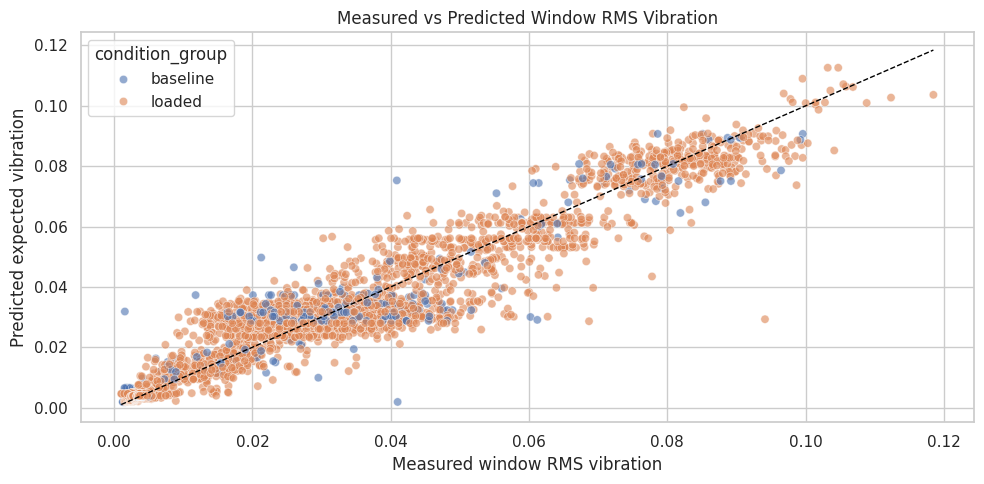

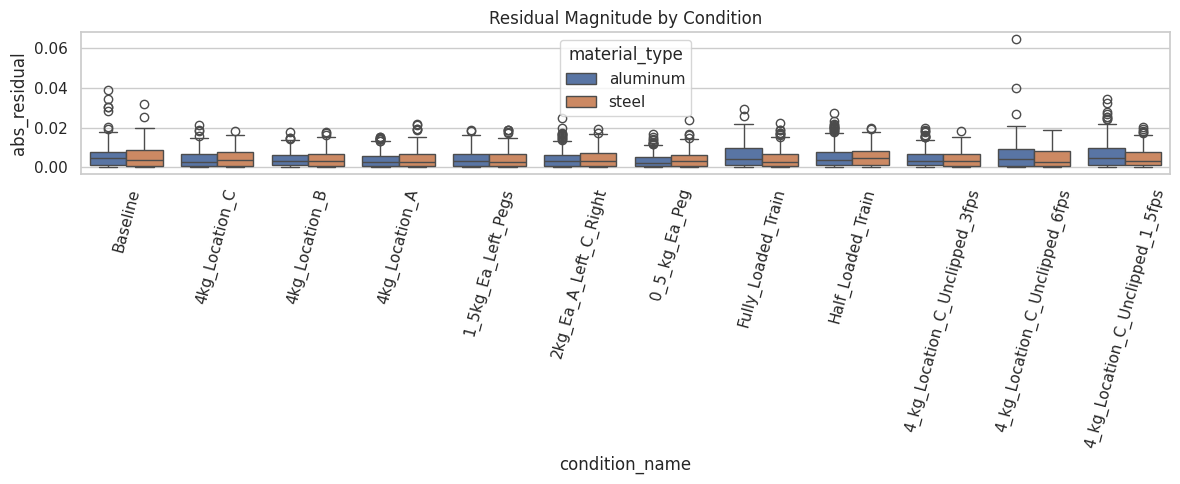

In [ ]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=features_df,
    x='g_rms',
    y='expected_vibration',
    hue='condition_group',
    alpha=0.6,
)
plt.plot(
    [features_df['g_rms'].min(), features_df['g_rms'].max()],
    [features_df['g_rms'].min(), features_df['g_rms'].max()],
    linestyle='--',
    color='black',
    linewidth=1,
)
plt.title('Measured vs Predicted Window RMS Vibration')
plt.xlabel('Measured window RMS vibration')
plt.ylabel('Predicted expected vibration')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=features_df, x='condition_name', y='abs_residual', hue='material_type')
plt.xticks(rotation=75)
plt.title('Residual Magnitude by Condition')
plt.tight_layout()
plt.show()

### Member 2 Deliverables Summary

Files produced by member 2:
- `run_metadata.csv`
- `aligned_runs.csv`
- `window_features.csv`
- `digital_twin_predictions.csv`

Recommended handoff to Member 3:
- use `window_features.csv` or `digital_twin_predictions.csv`
- classify `condition_group` first (`baseline` vs `loaded`)
- validate with `GroupKFold` grouped by `run_id`
- use `abs_residual` as one of the strongest downstream decision features
            


## 7. AI Classification

Recommended first task:
- classify `condition_group` or `condition_name`

Start with `condition_group` if you want a more stable result.


In [ ]:
clf_features = [
    'material', 'phase', 'speed_label', 'vel_mean', 'acc_mean',
    'g_mean_std', 'g_rms', 'g_ptp', 'g_diff_mean', 'dom_freq', 'spec_centroid', 'abs_residual'
]
target_clf = 'condition_group'

clf_cat_cols = ['material', 'phase', 'speed_label']
clf_num_cols = ['vel_mean', 'acc_mean', 'g_mean_std', 'g_rms', 'g_ptp', 'g_diff_mean', 'dom_freq', 'spec_centroid', 'abs_residual']

clf_pre = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), clf_cat_cols),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
    ]), clf_num_cols),
])

# 1. Update the Model Definition
clf_model = Pipeline([
    ('pre', clf_pre),
    # Keep the balanced weights
    ('model', RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=1, class_weight='balanced')),
])

# 2. Rerun using PROBABILITIES instead of hard predictions
print("Generating prediction probabilities...")
probas = cross_val_predict(
    clf_model,
    features_df[clf_features],
    features_df[target_clf],
    groups=features_df['run_id'],
    cv=cv,
    method='predict_proba', # <--- We changed this to get confidence scores
    n_jobs=1,
)

# 3. Apply a Custom Decision Threshold
# 'baseline' is alphabetically the first class, so it is at index 0 in the probas array.
# Lowering the threshold from 0.50 to 0.15 forces the model to catch more baseline runs.
CUSTOM_THRESHOLD = 0.15
features_df['pred_condition_group'] = np.where(probas[:, 0] >= CUSTOM_THRESHOLD, 'baseline', 'loaded')

# 4. Print the improved results
print("Binary Classification Results (Custom Threshold: 15%)")
print(classification_report(features_df[target_clf], features_df['pred_condition_group']))

labels = sorted(features_df[target_clf].dropna().unique())
cm = confusion_matrix(features_df[target_clf], features_df['pred_condition_group'], labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
display(cm_df)

Generating prediction probabilities...
Binary Classification Results (Custom Threshold: 15%)
              precision    recall  f1-score   support

    baseline       0.13      0.26      0.17       350
      loaded       0.93      0.85      0.88      3889

    accuracy                           0.80      4239
   macro avg       0.53      0.55      0.53      4239
weighted avg       0.86      0.80      0.83      4239



,baseline,loaded
baseline,90,260
loaded,599,3290


##Feature Importances

Calculating feature importances...


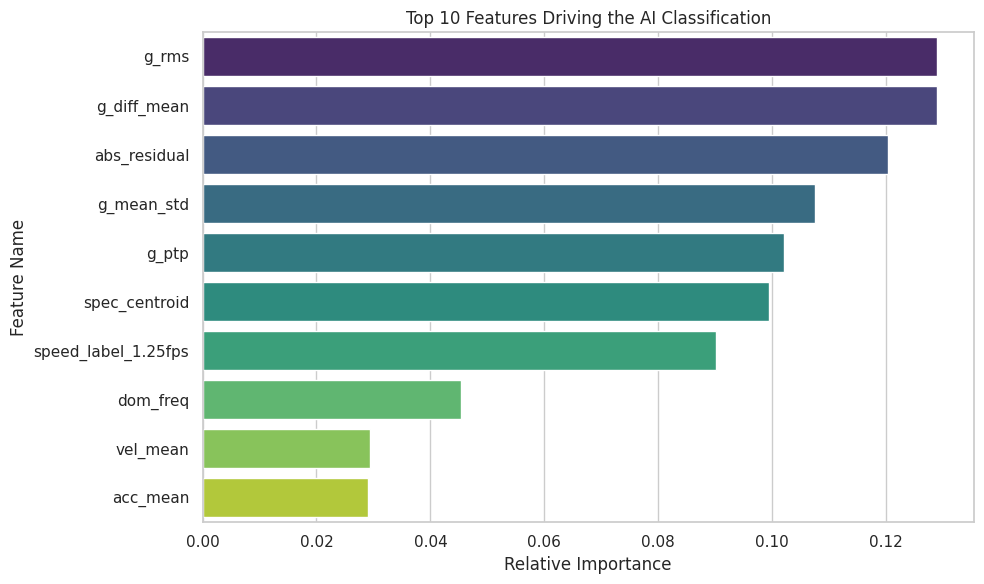

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Fit the pipeline on all the data so we can extract the weights
print("Calculating feature importances...")
clf_model.fit(features_df[clf_features], features_df[target_clf])

# 2. Extract the names of the features (handling the one-hot encoded categorical variables)
encoded_cats = clf_model.named_steps['pre'].transformers_[0][1].named_steps['onehot'].get_feature_names_out(clf_cat_cols)
all_feature_names = list(encoded_cats) + clf_num_cols

# 3. Pull the actual importance values from the Random Forest
importances = clf_model.named_steps['model'].feature_importances_

# 4. Bind them together and sort to find the top 10
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# 5. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Features Driving the AI Classification')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## 8. Context-Aware Decision Logic

Example logic:
- small residual -> continue
- large residual but known loaded condition -> adjust speed
- large residual and inconsistent classification -> slow down
- extreme residual -> stop


In [ ]:
# 1. Calculate statistical thresholds based ONLY on known safe baseline data
# We use the 95th percentile as a "Warning" and 99th percentile as "Critical"
baseline_residuals = features_df[features_df['condition_group'] == 'baseline']['abs_residual']
warning_threshold = baseline_residuals.quantile(0.95)
critical_threshold = baseline_residuals.quantile(0.99)

print(f"Calculated Warning Threshold (95th percentile): {warning_threshold:.5f}")
print(f"Calculated Critical Threshold (99th percentile): {critical_threshold:.5f}")

# 2. Define the decision rules using our new thresholds
def data_driven_decision(row):
    res = row['abs_residual']
    predicted = row['pred_condition_group']
    actual = row['condition_group'] # We keep this just to check our own false positives

    # CRITICAL: Extreme physical deviation regardless of what the AI thinks
    if res > critical_threshold:
        return 'stop'

    # WARNING: High deviation, but the AI knows it's just a heavy load
    elif res > warning_threshold and predicted == 'loaded':
        # If the AI predicted loaded, but it's actually baseline, that's a false positive.
        if predicted != actual:
            return 'slow_down'
        return 'adjust_speed'

    # WARNING: High deviation, and AI thinks it should be empty -> Something is physically wrong
    elif res > warning_threshold and predicted == 'baseline':
        return 'stop'

    # NORMAL: Operations are within normal bounds
    return 'continue'

# 3. Apply the logic to every window
features_df['decision_action'] = features_df.apply(data_driven_decision, axis=1)

print("\n--- Final Decision Action Counts ---")
print(features_df['decision_action'].value_counts())


# Format Classification Table for Member 4
classification_results = features_df[[
    'run_id', 'window_id', 'condition_group', 'pred_condition_group'
]]

# Format Decision Table for Member 4
decision_results = features_df[[
    'run_id', 'window_id', 'pred_condition_group', 'abs_residual', 'decision_action'
]]

# Export the CSVs
classification_results.to_csv('classification_results.csv', index=False)
decision_results.to_csv('decision_results.csv', index=False)

print("\nSUCCESS: Member 3 deliverables (classification_results.csv & decision_results.csv) saved.")

Calculated Warning Threshold (95th percentile): 0.01625
Calculated Critical Threshold (99th percentile): 0.03024

--- Final Decision Action Counts ---
decision_action
continue        4107
adjust_speed      92
stop              32
slow_down          8
Name: count, dtype: int64

SUCCESS: Member 3 deliverables (classification_results.csv & decision_results.csv) saved.


In [ ]:
# 9. Finer-Grained Classification
import warnings
warnings.filterwarnings('ignore') # Suppress warnings from rare classes in cross-validation

print("Training Finer-Grained Multi-Class Model...")

# 1. Change the target from the broad group to the exact specific condition
target_multi = 'condition_name'

# 2. Run the cross-validation prediction using the exact same balanced pipeline
features_df['pred_condition_name'] = cross_val_predict(
    clf_model,
    features_df[clf_features],
    features_df[target_multi],
    groups=features_df['run_id'],
    cv=cv,
    method='predict',
    n_jobs=1,
)

# 3. Print the results
print("\n Multi-Class Classification Results (Specific Conditions)")
# We only print the top-level accuracy and macro scores to keep the output clean
report = classification_report(features_df[target_multi], features_df['pred_condition_name'], output_dict=True)
print(f"Overall Accuracy for exact condition: {report['accuracy']:.2%}")
print(f"Macro F1-Score: {report['macro avg']['f1-score']:.2f}")

# 4. Optional: Save this advanced result for Member 4
classification_results = features_df[[
    'run_id', 'window_id', 'condition_group', 'pred_condition_group', 'condition_name', 'pred_condition_name'
]]
classification_results.to_csv('classification_results.csv', index=False)
print("Updated classification_results.csv with multi-class predictions.")

Training Finer-Grained Multi-Class Model...

 Multi-Class Classification Results (Specific Conditions)
Overall Accuracy for exact condition: 40.60%
Macro F1-Score: 0.40
Updated classification_results.csv with multi-class predictions.


## 9. Plots for the Report

These are the high-value plots for your final presentation.


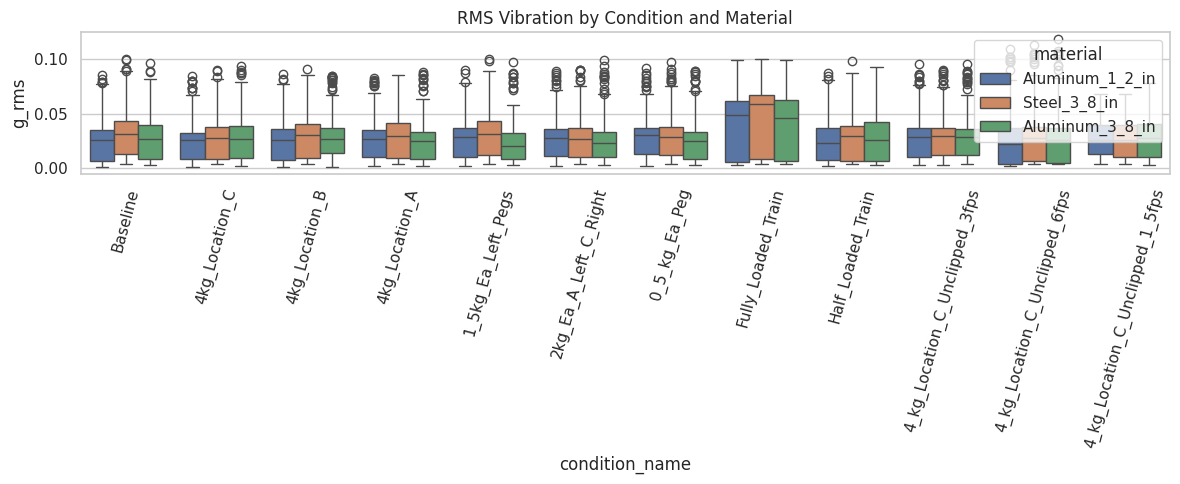

NameError: name 'decision_df' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=features_df, x='condition_name', y='g_rms', hue='material')
plt.xticks(rotation=75)
plt.title('RMS Vibration by Condition and Material')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=decision_df, x='condition_group', y='abs_residual')
plt.title('Residual Magnitude by Condition Group')
plt.tight_layout()
plt.show()


In [ ]:
sample_run_id = decision_df['run_id'].iloc[0]
sample_full = full_df[full_df['run_id'] == sample_run_id].copy().reset_index(drop=True)
sample_win = decision_df[decision_df['run_id'] == sample_run_id].copy().reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
axes[0].plot(sample_full['time_s'], sample_full['g_mean'])
axes[0].set_title('Measured Vibration')

axes[1].plot(sample_win.index, sample_win['expected_vibration'], label='expected')
axes[1].plot(sample_win.index, sample_win['g_mean_mean'], label='measured_window_mean')
axes[1].legend()
axes[1].set_title('Expected vs Measured Window Vibration')

action_map = {'continue': 0, 'adjust_speed': 1, 'slow_down': 2, 'stop': 3}
axes[2].step(sample_win.index, sample_win['decision_action'].map(action_map), where='post')
axes[2].set_yticks([0, 1, 2, 3])
axes[2].set_yticklabels(['continue', 'adjust_speed', 'slow_down', 'stop'])
axes[2].set_title('Decision Timeline')

plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

    baseline      0.131     0.257     0.173       350
      loaded      0.927     0.846     0.885      3889

    accuracy                          0.797      4239
   macro avg      0.529     0.552     0.529      4239
weighted avg      0.861     0.797     0.826      4239

Balanced Accuracy : 0.552
MCC               : 0.077
Class imbalance   : {'loaded': 3889, 'baseline': 350}


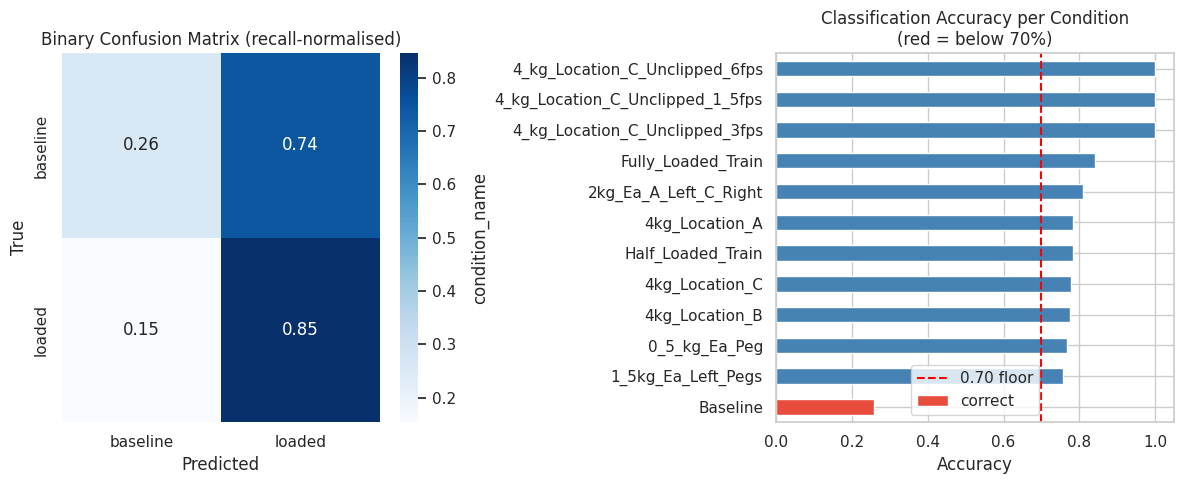

                                  precision    recall  f1-score   support

                   0_5_kg_Ea_Peg      0.182     0.191     0.186       351
              1_5kg_Ea_Left_Pegs      0.184     0.179     0.182       351
           2kg_Ea_A_Left_C_Right      0.188     0.194     0.191       351
4_kg_Location_C_Unclipped_1_5fps      1.000     1.000     1.000       424
  4_kg_Location_C_Unclipped_3fps      1.000     1.000     1.000       351
  4_kg_Location_C_Unclipped_6fps      1.000     1.000     1.000       306
                  4kg_Location_A      0.071     0.074     0.072       351
                  4kg_Location_B      0.137     0.134     0.135       351
                  4kg_Location_C      0.136     0.125     0.130       351
                        Baseline      0.134     0.117     0.125       350
              Fully_Loaded_Train      0.525     0.561     0.543       351
               Half_Loaded_Train      0.236     0.248     0.242       351

                        accuracy    

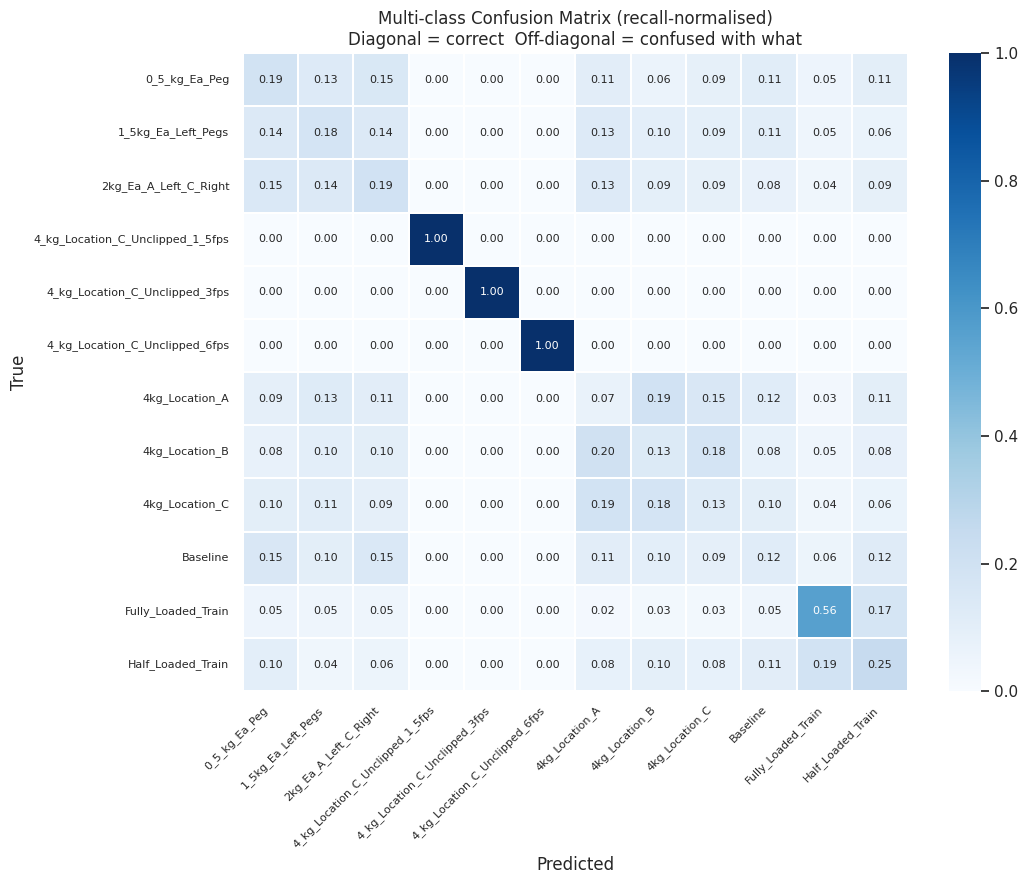


Action distribution:
decision_action
continue        4107
adjust_speed      92
stop              32
slow_down          8
Name: count, dtype: int64

False alarm rate (baseline flagged): 5.1%
Critical residuals → STOP         : 100.0%

Residual separation (Mann-Whitney p): 9.71e-01
Baseline mean: 0.00558  Loaded mean: 0.00469


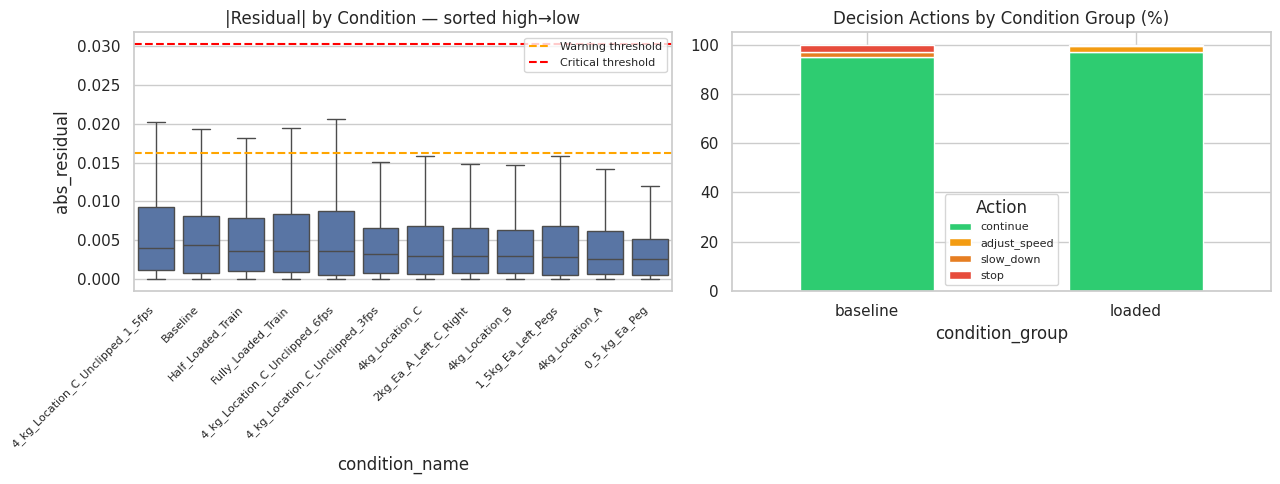

In [ ]:
# ── MEMBER 4 EVALUATION ───────────────────────────────────────
from scipy import stats
from sklearn.metrics import (
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
)

# ── 1. Binary Classification — baseline vs loaded ─────────────
y_true = features_df['condition_group']
y_pred = features_df['pred_condition_group']

print(classification_report(y_true, y_pred, digits=3))
print(f"Balanced Accuracy : {balanced_accuracy_score(y_true, y_pred):.3f}")
print(f"MCC               : {matthews_corrcoef(y_true, y_pred):.3f}")
print(f"Class imbalance   : {y_true.value_counts().to_dict()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
labels = sorted(y_true.unique())
cm = confusion_matrix(y_true, y_pred, labels=labels)
sns.heatmap(cm.astype(float) / cm.sum(axis=1, keepdims=True),
            annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Binary Confusion Matrix (recall-normalised)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# False-positive / false-negative breakdown per condition
fp_fn = features_df.copy()
fp_fn['correct'] = fp_fn['condition_group'] == fp_fn['pred_condition_group']
per_cond = fp_fn.groupby('condition_name')['correct'].mean().sort_values()
per_cond.plot(kind='barh', ax=axes[1],
              color=['#e74c3c' if v < 0.7 else 'steelblue' for v in per_cond])
axes[1].axvline(0.7, color='red', ls='--', lw=1.5, label='0.70 floor')
axes[1].set_title('Classification Accuracy per Condition\n(red = below 70%)')
axes[1].set_xlabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('eval_binary_classification.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 2. Multi-class Classification — condition_name ────────────
y_true_m = features_df['condition_name']
y_pred_m = features_df['pred_condition_name']

print(classification_report(y_true_m, y_pred_m, digits=3, zero_division=0))

labels_m = sorted(y_true_m.unique())
cm_m = confusion_matrix(y_true_m, y_pred_m, labels=labels_m)
cm_m_norm = cm_m.astype(float) / (cm_m.sum(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm_m_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_m, yticklabels=labels_m,
            ax=ax, linewidths=0.3, annot_kws={'size': 8})
ax.set_title('Multi-class Confusion Matrix (recall-normalised)\n'
             'Diagonal = correct  Off-diagonal = confused with what')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('eval_multiclass_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 3. Decision Action Evaluation ────────────────────────────
print("\nAction distribution:")
print(features_df['decision_action'].value_counts())

# False alarm rate — baseline windows that get flagged
baseline_rows = features_df[features_df['condition_group'] == 'baseline']
false_alarm = (baseline_rows['decision_action'] != 'continue').mean() * 100
print(f"\nFalse alarm rate (baseline flagged): {false_alarm:.1f}%")

# Critical safety — extreme residuals that get stopped
extreme = features_df[features_df['abs_residual'] >= critical_threshold]
extreme_stop = (extreme['decision_action'] == 'stop').mean() * 100
print(f"Critical residuals → STOP         : {extreme_stop:.1f}%")

# Residual separation — does loaded have higher residual than baseline?
baseline_res = features_df[features_df['condition_group'] == 'baseline']['abs_residual'].dropna()
loaded_res   = features_df[features_df['condition_group'] == 'loaded']['abs_residual'].dropna()
u_stat, u_p  = stats.mannwhitneyu(baseline_res, loaded_res, alternative='less')
print(f"\nResidual separation (Mann-Whitney p): {u_p:.2e}")
print(f"Baseline mean: {baseline_res.mean():.5f}  Loaded mean: {loaded_res.mean():.5f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residual by condition sorted
order = features_df.groupby('condition_name')['abs_residual'].mean().sort_values(ascending=False).index
sns.boxplot(data=features_df, x='condition_name', y='abs_residual',
            order=order, showfliers=False, ax=axes[0])
axes[0].axhline(warning_threshold, color='orange', ls='--', lw=1.5, label='Warning threshold')
axes[0].axhline(critical_threshold, color='red', ls='--', lw=1.5, label='Critical threshold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[0].set_title('|Residual| by Condition — sorted high→low')
axes[0].legend(fontsize=8)

# Action split per condition group
action_pal = {'continue':'#2ecc71','adjust_speed':'#f39c12','slow_down':'#e67e22','stop':'#e74c3c'}
action_order = [a for a in ['continue','adjust_speed','slow_down','stop']
                if a in features_df['decision_action'].values]
pivot = features_df.groupby(['condition_group','decision_action']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
cols = [c for c in action_order if c in pivot_pct.columns]
pivot_pct[cols].plot(kind='bar', stacked=True,
                     color=[action_pal[c] for c in cols],
                     ax=axes[1], edgecolor='white')
axes[1].set_title('Decision Actions by Condition Group (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Action', fontsize=8)

plt.tight_layout()
plt.savefig('eval_decision_logic.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Recommended Project Claims

Use claims like these in the report:
- The digital twin predicts expected vibration from operating context.
- Residuals quantify deviation between expected and measured behavior.
- Context helps distinguish normal load changes from abnormal conditions.
- Grouped run-level validation avoids data leakage and gives more credible results.
- The pipeline closes the loop from sensing to reasoning to actuation.


## we use AI tool such as chatgpt and claude to help reorganize the train-run dataset parsing logic, improve synchronization and feature-engineering code structure in the notebook, refine the Random Forest digital twin / classification pipeline wording, and integrate teammate-written sections into a consistent final report. AI was also used to help rewrite technical explanations of residuals, thresholds, confusion-matrix results, and decision-logic interpretation into clearer academic language. The team still selected the final methodology, verified that the reported results matched the actual notebook outputs, and made the final decisions on implementation, evaluation, and report content.